# Proyek Klasifikasi Gambar: [Intel Image Classification]
- **Nama:** [Hafiz Satria]
- **Email:** [azizanhafiz123@gmail.com]
- **ID Dicoding:** [Hafiz Satria]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Libraries untuk pemrosesan data gambar
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

## Data Preparation

### Data Loading

In [4]:
# Import module yang disediakan google colab untuk kebutuhan upload file

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"azizanhafiz","key":"394323afff4133db00a43daccc91c896"}'}

In [5]:
import os

# Pastikan direktori ~/.kaggle ada
os.makedirs('/root/.kaggle', exist_ok=True)

# Download kaggle dataset and unzip the file
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download puneet6060/intel-image-classification
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [6]:
import os
import shutil

In [7]:
# Direktori awal untuk train dan test
train_dir = "seg_train/seg_train"
test_dir = "seg_test/seg_test"

# Direktori baru untuk dataset gabungan
combined_dir = "data/dataset"# Direktori awal untuk train dan test
train_dir = "seg_train/seg_train"
test_dir = "seg_test/seg_test"

# Direktori baru untuk dataset gabungan
combined_dir = "data/dataset"

In [8]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [9]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

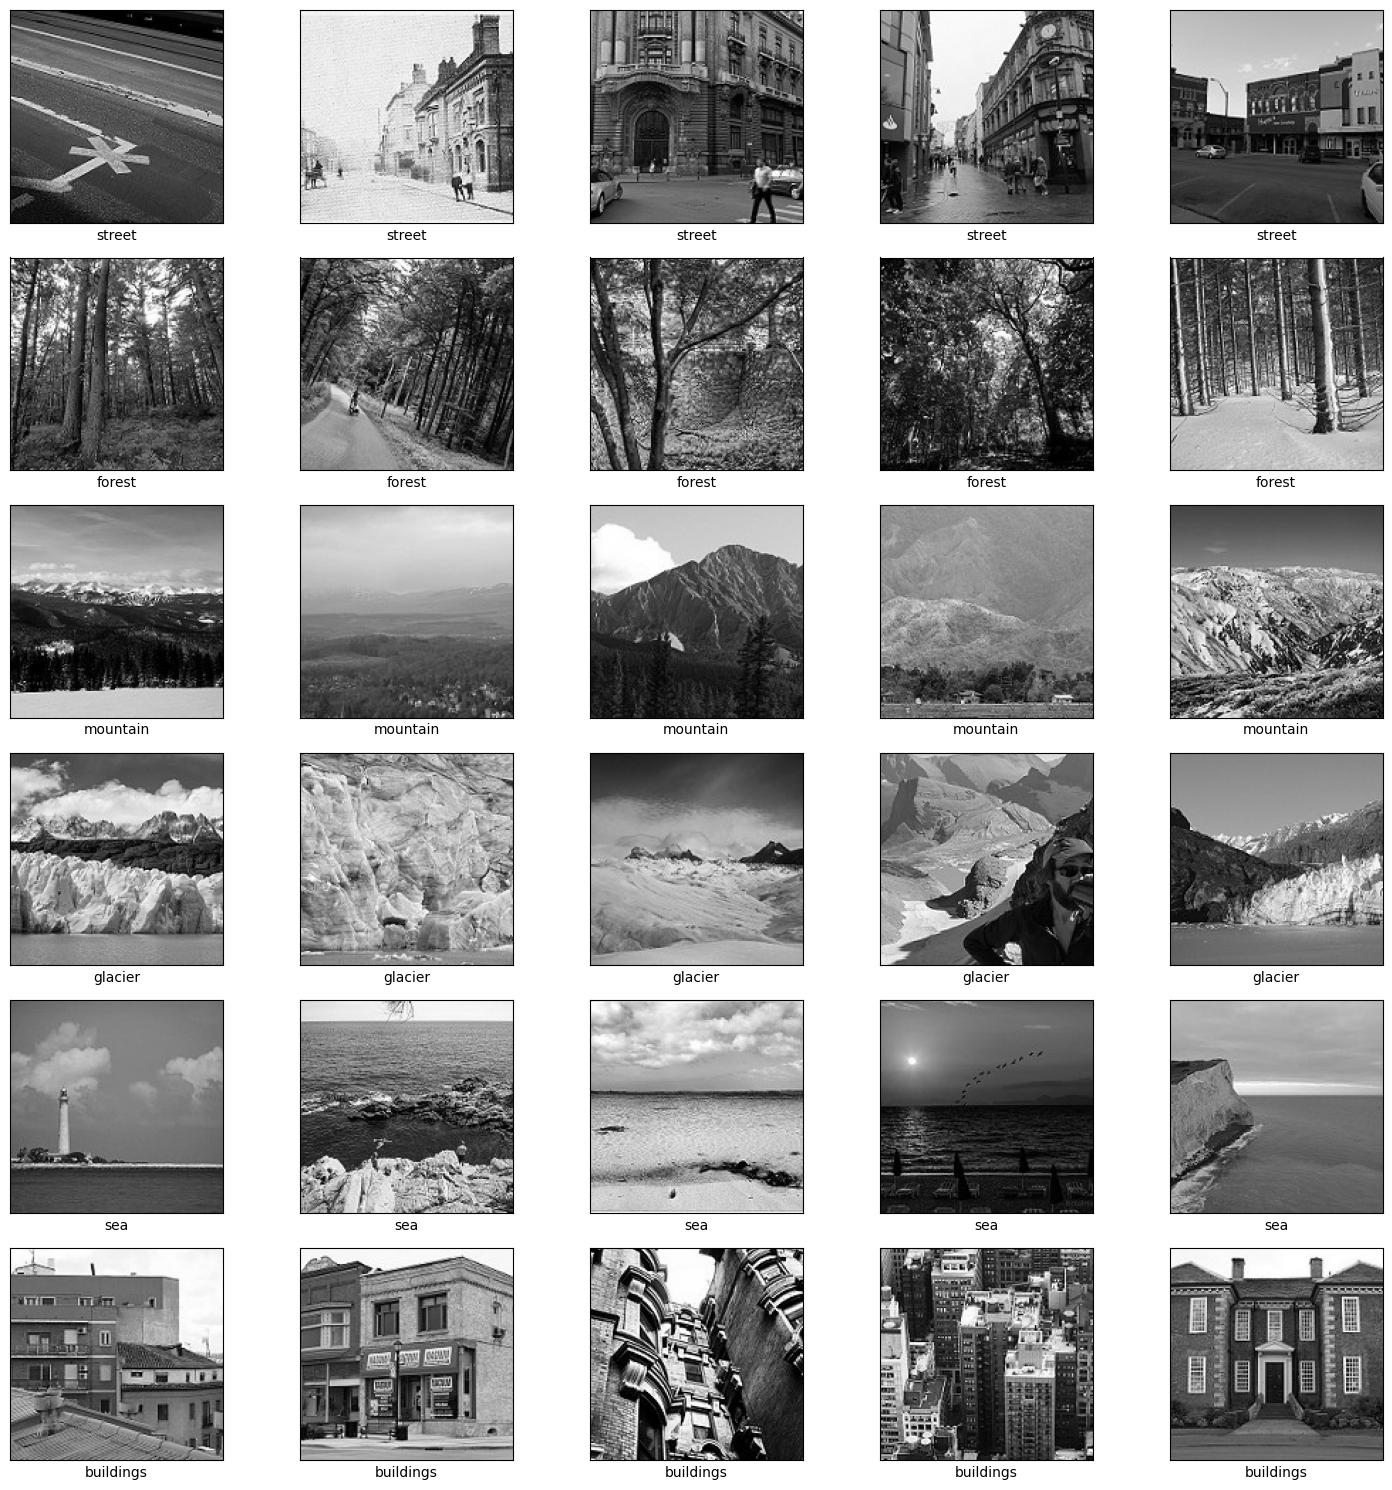

In [10]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
intel_image = {}

# Tentukan path sumber train
path = "seg_train/"
path_sub = os.path.join(path, "seg_train")
for i in os.listdir(path_sub):
  intel_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "data/dataset"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(intel_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
  images = np.random.choice(intel_image[class_name], 5, replace=False)

  for j, image_name in enumerate(images):
    img_path = os.path.join(path_sub, class_name, image_name)
    img = Image.open(img_path).convert("L") # Konversi menjadi skala keabuan
    axs[i, j].imshow(img, cmap='gray')
    axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

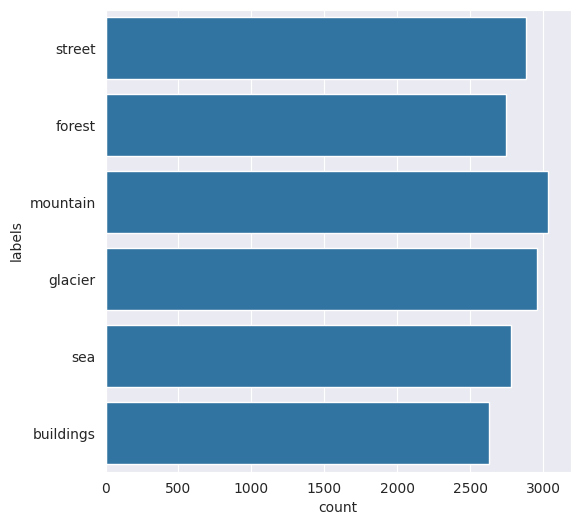

In [11]:
# Definisikan path sumber
intel_path = "data/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(intel_path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split('/')[-1])
    file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

### Data Preprocessing

In [12]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  sudut = random.randint(0,180)
  return rotate(img, sudut)

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  sudut = random.randint(0,180)
  return rotate(img, -sudut)

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  return np.flipud(img)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  img = adjust_gamma(img, gamma=0.5,gain=1)
  return img

# Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  return cv2.GaussianBlur(img, (9,9),0)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  transform = AffineTransform(shear=0.2)
  shear_image = warp(img, transform, mode="wrap")
  return shear_image

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  transform = AffineTransform(translation=(0,40))
  warp_image = warp(img, transform, mode="wrap")
  return warp_image

In [13]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }
# Path utama dataset (ganti sesuai lokasi datasetmu)
base_path = "data/dataset"
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

images_to_generate = 2000 # Jumlah total gambar baru PER KELAS

for folder in classes:
    images_path = os.path.join(base_path, folder)

    # Ambil daftar gambar asli di folder tersebut
    images = [os.path.join(images_path, im) for im in os.listdir(images_path)
              if im.endswith(('.jpg', '.png', '.jpeg'))]

    if not images:
        continue

    print(f"Sedang menambah {images_to_generate} gambar ke folder: {folder}")

    i = 1
    while i <= images_to_generate:
        image_path = random.choice(images)
        try:
            # Baca gambar dan pastikan formatnya benar
            original_image = io.imread(image_path)
            transformed_image = original_image

            # Pilih jumlah transformasi acak
            transformation_count = random.randint(1, len(transformations))

            for _ in range(transformation_count):
                key = random.choice(list(transformations))
                transformed_image = transformations[key](transformed_image)

            # --- FIX ERROR CV_64F ---
            # Paksa jadi 8-bit (0-255) sebelum disimpan oleh OpenCV
            transformed_image = img_as_ubyte(transformed_image)

            # Simpan di folder yang sama dengan nama file yang berbeda agar tidak menimpa yang asli
            new_filename = f"aug_{i}_{os.path.basename(image_path)}"
            new_image_path = os.path.join(images_path, new_filename)

            # Jika gambar 3 channel (RGB), konversi ke BGR sebelum disimpan cv2
            if len(transformed_image.shape) == 3 and transformed_image.shape[2] == 3:
                transformed_image = cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR)

            cv2.imwrite(new_image_path, transformed_image)
            i += 1

        except Exception as e:
            # Skip jika ada file yang korup atau error depth tadi
            pass

print("Augmentasi selesai! Semua gambar baru sudah masuk ke folder masing-masing.")


Sedang menambah 2000 gambar ke folder: street
Sedang menambah 2000 gambar ke folder: forest
Sedang menambah 2000 gambar ke folder: mountain
Sedang menambah 2000 gambar ke folder: glacier
Sedang menambah 2000 gambar ke folder: sea
Sedang menambah 2000 gambar ke folder: buildings
Augmentasi selesai! Semua gambar baru sudah masuk ke folder masing-masing.


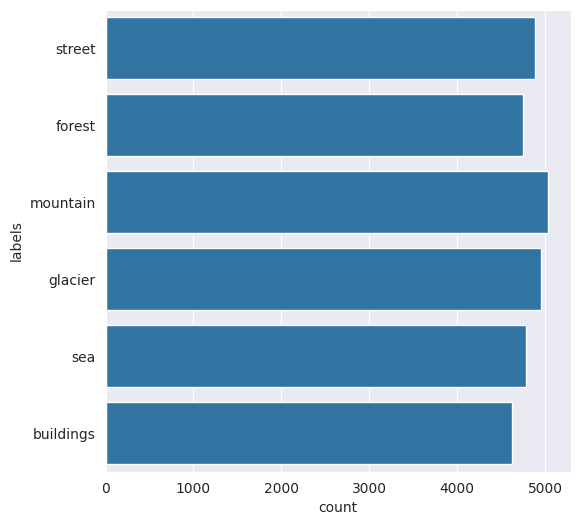

In [14]:
# Definisikan path sumber
intel_path = "data/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(intel_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

#### Split Dataset

In [15]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'data/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
buildings,4628
forest,4745
glacier,4957
mountain,5037
sea,4784
street,4883


In [16]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [17]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [18]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "data/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels   
test   buildings     918
       forest        957
       glacier       990
       mountain     1025
       sea           944
       street        973
train  buildings    3710
       forest       3788
       glacier      3967
       mountain     4012
       sea          3840
       street       3910
dtype: int64 


                                            path     labels    set
23939   data/dataset/buildings/aug_696_19624.jpg  buildings   test
6124             data/dataset/mountain/14230.jpg   mountain  train
18571           data/dataset/buildings/19032.jpg  buildings  train
22443       data/dataset/street/aug_968_7454.jpg     street  train
25954  data/dataset/buildings/aug_1463_11621.jpg  buildings   test


In [19]:
for index, row in tq(df_all.iterrows()):
  # Deteksi filepath
  file_path = row['path']
  if os.path.exists(file_path) == False:
    file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

  # Buat direktori tujuan folder
  if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
    os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

  # Tentukan tujuan file
  destination_file_name = file_path.split('/')[-1]
  file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

  # Salin file dari sumber ke tujuan
  if os.path.exists(file_dest) == False:
    shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [20]:
# Definisikan direktori utama
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

def hitung_gambar(direktori, label):
    print(f"\n--- Menghitung Gambar di {label} ---")
    # Ambil semua sub-folder (nama kelas) di dalam direktori
    classes = [d for d in os.listdir(direktori) if os.path.isdir(os.path.join(direktori, d))]

    total_semua = 0
    for kelas in sorted(classes):
        path_kelas = os.path.join(direktori, kelas)
        jumlah = len(os.listdir(path_kelas))
        total_semua += jumlah
        print(f"Total {kelas}: {jumlah} gambar")

    print(f"TOTAL KESELURUHAN {label}: {total_semua}")

# Jalankan fungsi untuk Train dan Test
hitung_gambar(TRAIN_DIR, "TRAINING SET")
hitung_gambar(TEST_DIR, "TEST SET")


--- Menghitung Gambar di TRAINING SET ---
Total buildings: 3710 gambar
Total forest: 3788 gambar
Total glacier: 3967 gambar
Total mountain: 4012 gambar
Total sea: 3840 gambar
Total street: 3910 gambar
TOTAL KESELURUHAN TRAINING SET: 23227

--- Menghitung Gambar di TEST SET ---
Total buildings: 918 gambar
Total forest: 957 gambar
Total glacier: 990 gambar
Total mountain: 1025 gambar
Total sea: 944 gambar
Total street: 973 gambar
TOTAL KESELURUHAN TEST SET: 5807


In [21]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=64,
                                              target_size=(160,160),
                                              color_mode="rgb",
                                              class_mode='categorical',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=64,
                                                   target_size=(160,160),
                                                color_mode="rgb",
                                                   class_mode='categorical',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(160,160),
                                                  color_mode="rgb",
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 18583 images belonging to 6 classes.
Found 4644 images belonging to 6 classes.
Found 5807 images belonging to 6 classes.


## Modelling

In [22]:
transfer_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
transfer_model.trainable = True
for layer in transfer_model.layers[:120]: # Kunci layer bawah, buka layer atas
    layer.trainable = False

In [24]:
# tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()
model_1.add(transfer_model)

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))


# Global layer
model_1.add(GlobalAveragePooling2D())
# Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# Dropout Layer
model_1.add(Dropout(0.5))

# Final Dense layer
model_1.add(Dense(6, activation='softmax'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00005),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,631,782 (10.04 MB)

 Trainable params: 1,998,630 (7.62 MB)

 Non-trainable params: 633,152 (2.42 MB)

None


In [25]:
# Ambil semua label dari generator
labels = train_generator.classes

# Hitung bobot secara otomatis untuk 12 kelas
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Ubah menjadi format dictionary untuk model.fit
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.043519766397125), 1: np.float64(1.021829979104806), 2: np.float64(0.9757929006511237), 3: np.float64(0.9648494288681204), 4: np.float64(1.0081922743055556), 5: np.float64(0.9901427962489343)}


In [26]:
%time
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Fitting / training model
history = model_1.fit(train_generator,
                        epochs=50,
                        batch_size=64,
                        validation_data=validation_generator,
                        callbacks=[early_stop],
                        class_weight = class_weights)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 4.77 µs
Epoch 1/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 84s 191ms/step - accuracy: 0.7145 - loss: 0.7951 - val_accuracy: 0.8648 - val_loss: 0.3597
Epoch 2/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.8623 - loss: 0.4127 - val_accuracy: 0.9029 - val_loss: 0.2704
Epoch 3/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.9014 - loss: 0.3037 - val_accuracy: 0.9040 - val_loss: 0.2854
Epoch 4/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.9299 - loss: 0.2152 - val_accuracy: 0.9001 - val_loss: 0.2949
Epoch 5/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9546 - loss: 0.1433 - val_accuracy: 0.9037 - val_loss: 0.3175
Epoch 6/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.9706 - loss: 0.0967 - val_accuracy: 0.9007 - val_loss: 0.3667
Epoch 7/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.9826 - loss: 0.0615 - val_accuracy: 0.9046 - val_loss: 0.3400


## Evaluasi dan Visualisasi

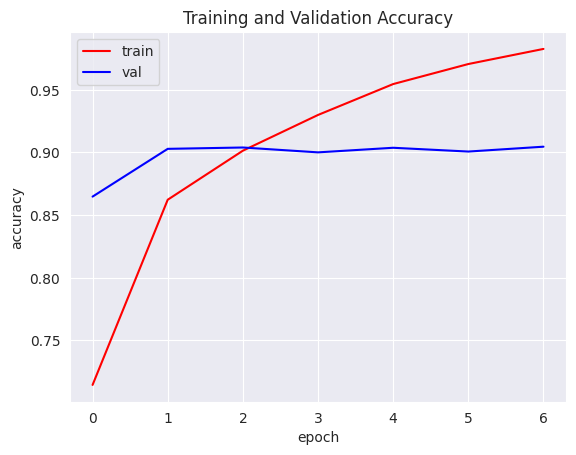

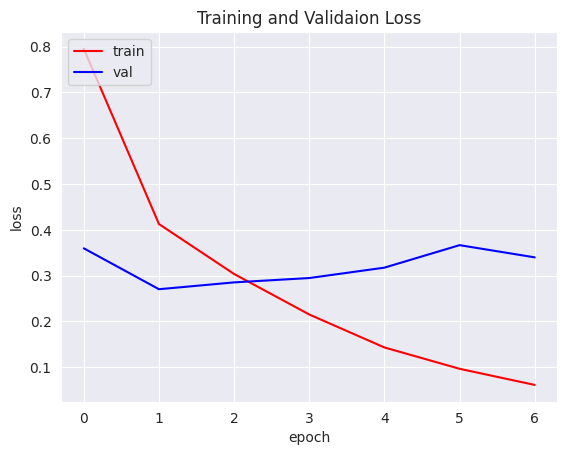

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

5807/5807 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step


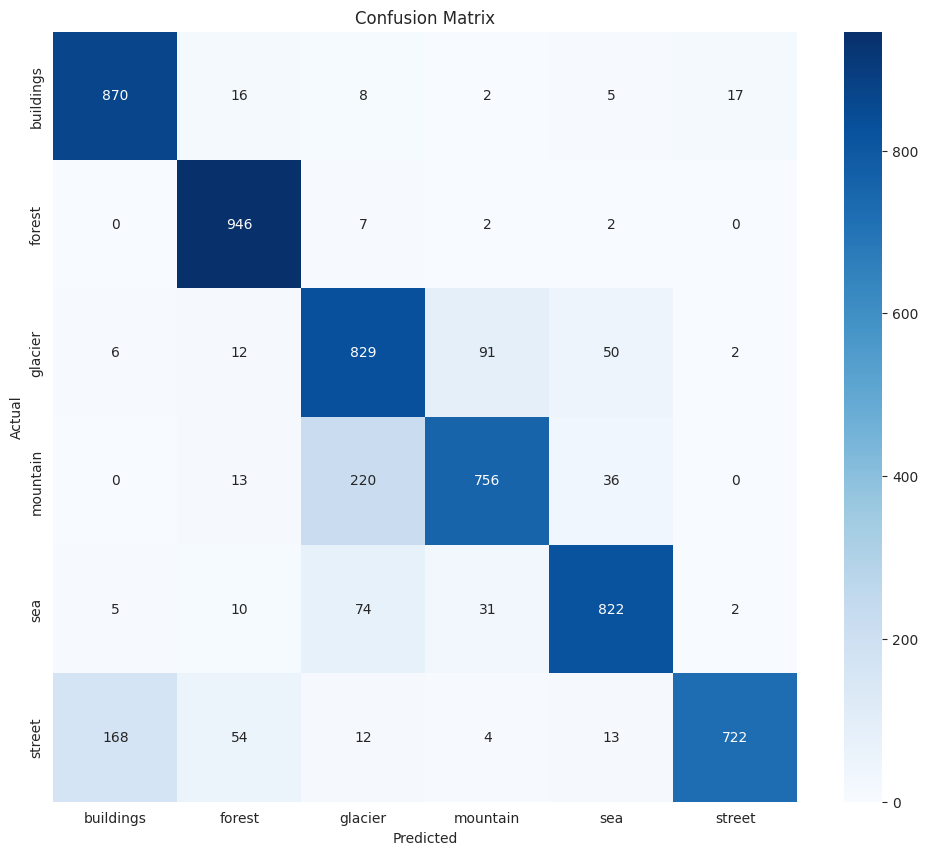


Classification Report:

              precision    recall  f1-score   support

   buildings     0.8294    0.9477    0.8846       918
      forest     0.9001    0.9885    0.9422       957
     glacier     0.7209    0.8374    0.7748       990
    mountain     0.8533    0.7376    0.7912      1025
         sea     0.8858    0.8708    0.8782       944
      street     0.9717    0.7420    0.8415       973

    accuracy                         0.8516      5807
   macro avg     0.8602    0.8540    0.8521      5807
weighted avg     0.8598    0.8516    0.8506      5807



In [28]:
# 1. Reset generator
test_generator.reset()

# 2. Prediksi (hasilnya berupa probabilitas untuk tiap kelas)
preds_1 = model_1.predict(test_generator, verbose=1)

# 3. Ambil indeks kelas dengan nilai tertinggi (Multi-class handling)
# Ini menggantikan logika <= 0.5
y_pred = np.argmax(preds_1, axis=1)

# 4. Ambil nama kelas secara otomatis dari generator
target_names = list(test_generator.class_indices.keys())

# 5. Buat Confusion Matrix
cm_data = confusion_matrix(test_generator.classes, y_pred)
cm = pd.DataFrame(cm_data, index=target_names, columns=target_names)

# 6. Plot Confusion Matrix
plt.figure(figsize=(12, 10)) # Ukuran lebih besar karena ada 12 kelas
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 7. Print Classification Report
print("\nClassification Report:\n")
print(classification_report(test_generator.classes, y_pred, target_names=target_names, digits=4))

In [29]:
from sklearn.metrics import accuracy_score

# Hitung akurasi dari data asli (test_generator.classes) dan hasil tebakan (y_pred)
acc = accuracy_score(test_generator.classes, y_pred)
print(f"Total Akurasi Model: {acc * 100:.2f}%")

Total Akurasi Model: 85.16%


## Konversi Model

In [32]:
# Gunakan .export() untuk format SavedModel (standar TensorFlow)
model_1.export('intel_model')

Saved artifact at 'intel_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137994706061264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706064144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706066832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706066448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706065296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706067024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706065488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706067600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706067216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706065104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137994706063952

In [33]:
# Inisialisasi converter dari SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model('intel_model')

# Konversi model
tflite_model = converter.convert()

# Simpan sebagai file .tflite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)


In [38]:
!pip install tensorflowjs --quiet

!python -m tensorflowjs.converters.converter --input_format=tf_saved_model intel_model tfjs_model_folder

2026-03-24 21:28:22.886866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774387702.907684   11751 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774387702.918325   11751 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774387702.940008   11751 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774387702.940033   11751 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774387702.940038   11751 computation_placer.cc:177] computation placer alr

In [39]:
from google.colab import files

# 1. Download TFLite langsung
print("Mengunduh TFLite...")
files.download('model.tflite')

# 2. Zip dan Download SavedModel
print("Mengunduh SavedModel (Zip)...")
shutil.make_archive('intel_model_saved', 'zip', 'intel_model')
files.download('intel_model_saved.zip')

# 3. Zip dan Download TFJS
print("Mengunduh TFJS (Zip)...")
shutil.make_archive('tfjs_model', 'zip', 'tfjs_model_folder')
files.download('tfjs_model.zip')

Mengunduh TFLite...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mengunduh SavedModel (Zip)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mengunduh TFJS (Zip)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
!pip freeze > requirements.txt

In [44]:
%%writefile label.txt
buildings
forest
glacier
mountain
sea
street

Writing label.txt


## Inference (Optional)

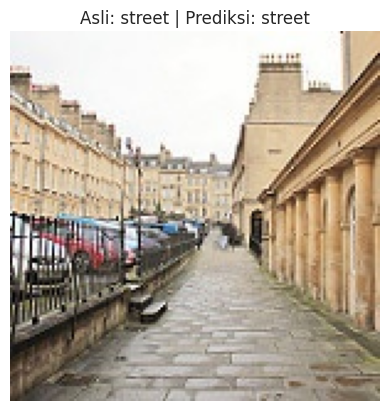

In [40]:
# 1. Load kembali model yang sudah di-export tadi
reloaded_model = tf.saved_model.load('intel_model')
infer = reloaded_model.signatures["serving_default"]

# 2. Ambil satu gambar acak dari folder test (sesuaikan path-nya)
test_dir = 'seg_test/seg_test' # Sesuaikan dengan struktur folder kamu
random_category = random.choice(os.listdir(test_dir))
random_image = random.choice(os.listdir(os.path.join(test_dir, random_category)))
img_path = os.path.join(test_dir, random_category, random_image)

# 3. Preprocessing gambar agar sesuai input model (misal 150x150)
img = image.load_img(img_path, target_size=(150, 150)) # Sesuaikan ukuran input modelmu
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0 # Normalisasi jika modelmu dilatih dengan cara ini

# 4. Melakukan Prediksi
# Nama input biasanya 'input_layer' atau 'conv2d_input', sesuaikan jika error
prediction = infer(tf.constant(img_array))
output_key = list(prediction.keys())[0]
result = prediction[output_key].numpy()

# 5. Tampilkan Hasil
classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] # Sesuaikan urutan class kamu
predicted_class = classes[np.argmax(result)]

plt.imshow(img)
plt.title(f"Asli: {random_category} | Prediksi: {predicted_class}")
plt.axis('off')
plt.show()